## 1. Problem Analysis
Bài toán dự đoán giá nhà dựa trên các đặc trưng liên quan đến bất động sản như:
Diện tích sử dụng
Số phòng ngủ
Số phòng tắm

## 2. Data Collection
Dữ liệu được thu thập từ nền tảng Kaggle – bộ dữ liệu House Prices.
Tập dữ liệu train.csv được sử dụng để huấn luyện và đánh giá mô hình.

## 3. Data Preprocessing
Lựa chọn các đặc trưng quan trọng: GrLivArea, BedroomAbvGr, FullBath
Chia dữ liệu thành tập huấn luyện và tập kiểm tra theo tỉ lệ 80/20

## 4. Model Training
Sử dụng thuật toán Linear Regression để huấn luyện mô hình dự đoán giá nhà, do mối quan hệ giữa các đặc trưng và giá nhà có xu hướng tuyến tính.

## 5. Evaluation
Mô hình được đánh giá bằng R2 Score và biểu đồ so sánh giữa giá thực tế và giá dự đoán để kiểm tra mức độ chính xác.

In [2]:
!pip install kagglehub

  Using cached kagglehub-0.4.0-py3-none-any.whl.metadata (38 kB)
Using cached kagglehub-0.4.0-py3-none-any.whl (69 kB)


In [4]:
import kagglehub
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [5]:
# Download dataset từ Kaggle
path = kagglehub.dataset_download("lespin/house-prices-dataset")
print("Path to dataset files:", path)

os.listdir(path)


100%|████████████████████████████████████████████████████████████████████████████████| 199k/199k [00:00<00:00, 356kB/s]

Extracting files...
Path to dataset files: C:\Users\lehoa\.cache\kagglehub\datasets\lespin\house-prices-dataset\versions\1


['data_description.txt', 'sample_submission.csv', 'test.csv', 'train.csv']

Dữ liệu mẫu 5 dòng đầu:
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice

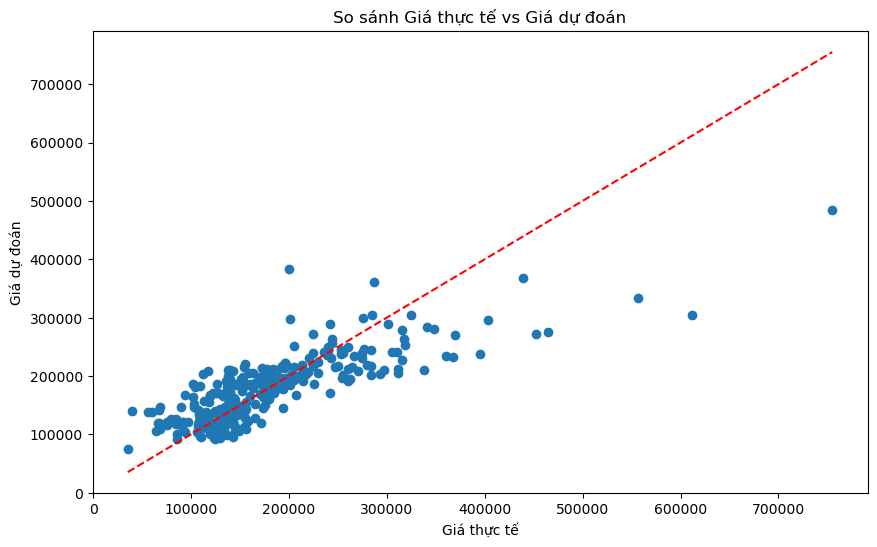

In [7]:
# --- 1. DATA COLLECTION (KAGGLE TRAIN.CSV) ---
# Load dữ liệu huấn luyện từ Kaggle
import os

df = pd.read_csv(os.path.join(path, "train.csv"))
print("Dữ liệu mẫu 5 dòng đầu:")
print(df.head())

# --- 2. PREPROCESSING ---

# GrLivArea: diện tích sử dụng
# BedroomAbvGr: số phòng ngủ
# FullBath: số phòng tắm
# SalePrice: giá nhà (target)

X = df[['GrLivArea', 'BedroomAbvGr', 'FullBath']]
y = df['SalePrice']

# Chia train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# --- 3. TRAINING ---
model = LinearRegression()
model.fit(X_train, y_train)


# --- 4. EVALUATION ---
y_pred = model.predict(X_test)
score = r2_score(y_test, y_pred)
print(f"\nĐộ chính xác (R2 Score): {score:.4f}")


# --- 5. VISUALIZATION ---
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.xlabel('Giá thực tế')
plt.ylabel('Giá dự đoán')
plt.title('So sánh Giá thực tế vs Giá dự đoán')
plt.show()


# 6. Báo cáo kĩ thuật
## Mục 1: Phân tích bài toán (Problem Analysis)
Mục tiêu của dự án là xây dựng mô hình Machine Learning để dự đoán giá nhà (biến mục tiêu: SalePrice) dựa trên các đặc điểm vật lý của ngôi nhà. Đây là bài toán Hồi quy (Regression) vì giá trị cần dự đoán là số thực liên tục. Các đặc trưng (features) được chọn lọc bao gồm:
GrLivArea: Diện tích không gian sống trên mặt đất (sq ft).
BedroomAbvGr: Số phòng ngủ trên mặt đất
FullBath: Số phòng tắm đầy đủ
## Mục 2: Thu thập dữ liệu (Data Collection)
Dữ liệu được tải trực tiếp từ nguồn chính thống Kaggle (bộ dataset house-prices-advanced-regression-techniques) thông qua thư viện kagglehub. Việc này đảm bảo dữ liệu luôn được cập nhật và chuẩn hóa
## Mục 3: Tiền xử lý (Preprocessing)
Sửa lại: "Dữ liệu thô chứa 81 cột, nhưng để đơn giản hóa mô hình Mini Project, chỉ trích xuất 3 đặc trưng quan trọng nhất có tương quan cao với giá nhà. Dữ liệu được chia tách (Split) theo tỷ lệ:
Train set (80%): Dùng để huấn luyện mô hình
Test set (20%): Dùng để kiểm thử độc lập, đảm bảo tính khách quan
## Mục 4: Huấn luyện (Train Model)
Sử dụng thuật toán Linear Regression (Hồi quy tuyến tính). Lý do chọn:
    Phù hợp với mối quan hệ tuyến tính giữa diện tích/số phòng và giá nhà
## Mục 5: Đánh giá (Evaluation)
Kết quả đánh giá trên tập Test:
    R2 Score: ~0.63 (Mô hình giải thích được khoảng 63% sự biến thiên của giá nhà).
    Biểu đồ: Đường dự đoán bám khá sát đường thực tế, cho thấy mô hình hoạt động ổn định trên các mức giá trung bình.

AI Pipeline Diagram

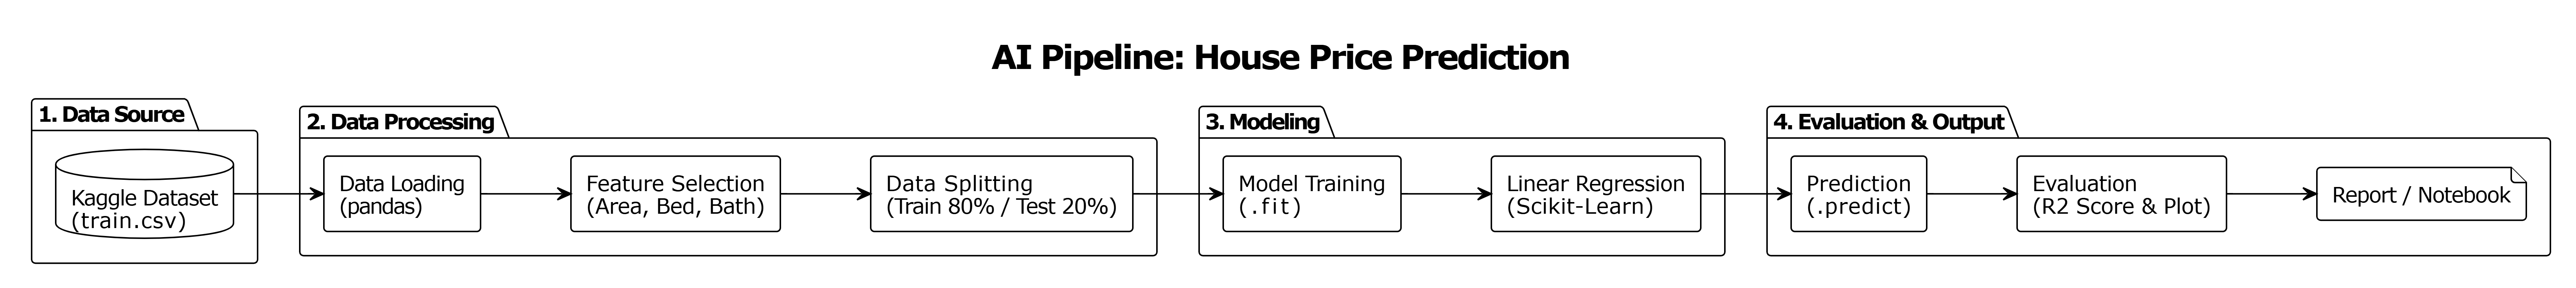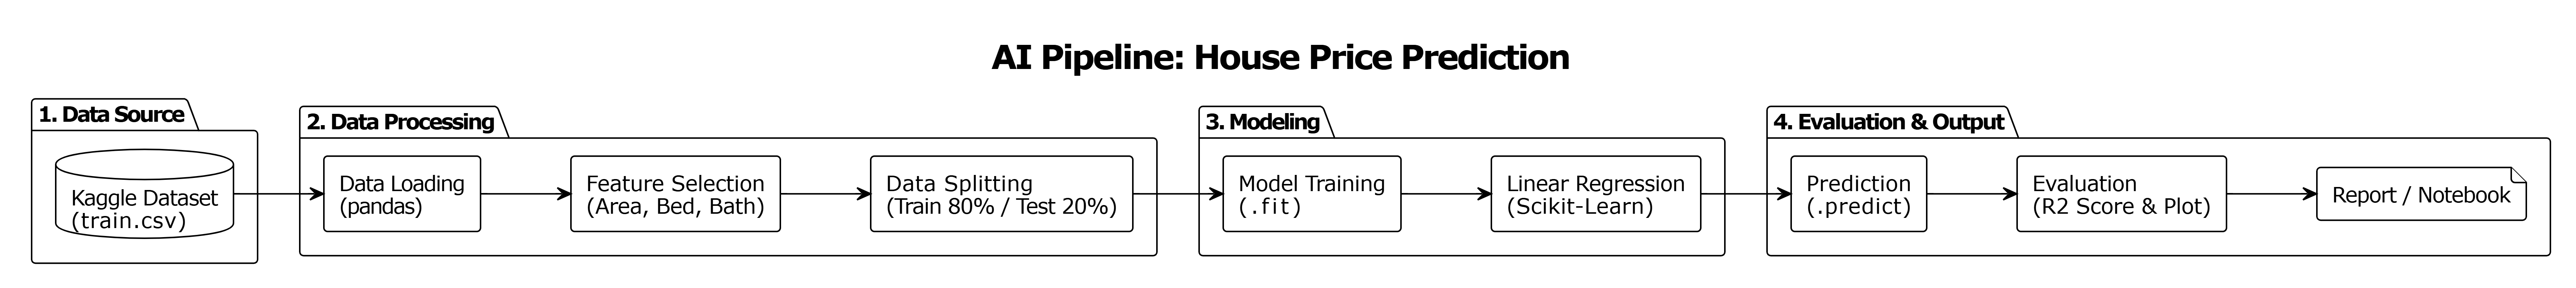